In [1]:
import torch
from torch.nn.functional import pad
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

In [2]:
from tqdm.notebook import tqdm

In [3]:
# need to add path using os and sys first
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))
# and now we can import the model
from models.model import MainModelFauxMixing as MainModel

In [4]:
from datasets import load_from_disk

In [5]:
import tokenmonster

In [6]:
tokenizer_file = "english-8000-balanced-v1"

In [7]:
vocab = tokenmonster.load_multiprocess_safe(tokenizer_file)

In [8]:
initial_vocab_size = len(vocab)

In [9]:
pad_idx = initial_vocab_size
mask_idx = initial_vocab_size + 1

In [10]:
vocab_size = initial_vocab_size + 2

In [11]:
question_len = 256
context_len = 512
answer_len = 100

In [12]:
embedding_dim = 512
num_heads = 8
target_len = answer_len
num_layers = 1
phm_factor = 8
lm_head_phm_factor = 2
batch_size = 50
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [13]:
checkpoint_dir = "checkpoints"
path = f"{checkpoint_dir}/crfmlm_modelfaux.pt"

In [14]:
squad_train_file = "data/squad_train"
squad = load_from_disk(squad_train_file)

In [15]:
masking_prob = 0.15
mask_token_prob = 0.8
random_token_prob = 0.1
leave_token_prob = 0.1

In [16]:
def collate_fn(batch, question_key, context_key, answer_key):
    """
    Each batch has 3 elements: instruction, context, response
    However since their lengths may vary, we need to pad them.

    For response, must ensure that we add eos token and then begin padding.
    """
    answers = []

    for elem in batch:
        i = elem[question_key]
        c = elem[context_key]
        r = elem[answer_key]

        # combine them all into one sequence
        combined = torch.cat((i, c, r))
        answers.append(combined)

    # the answers are the targets for masked language modeling
    # Pad answers to answer_len + question_len + context_len
    answers = [pad(r, (0, (answer_len + question_len + context_len) - len(r)), value=pad_idx) for r in answers]

    answers = torch.stack(answers)

    answer_masking = torch.rand(answers.shape) < masking_prob
    targets = torch.ones(answers.shape) * pad_idx
    # ensure targets and answers are of the same dtype
    targets = targets.type_as(answers)
    targets[answer_masking] = answers[answer_masking]

    # 80% of the time, replace masked input tokens with tokenizer.mask_token ([MASK])
    # 10% of the time, replace with random token
    # 10% of the time, keep original
    masked_answers = answers.clone()
    masking_mask = answer_masking & (torch.rand(answers.shape) < mask_token_prob)
    random_mask = answer_masking & ~masking_mask & (torch.rand(answers.shape) < random_token_prob)
    masked_answers[masking_mask] = mask_idx
    masked_answers[random_mask] = torch.randint(0, vocab_size, (random_mask.sum().item(),))

    return masked_answers, targets, answers

In [17]:
def squad_collate_fn(batch):
    return collate_fn(batch, "question", "context", "answers")

In [18]:
squadDataloader = DataLoader(squad, batch_size=batch_size, shuffle=True, collate_fn=squad_collate_fn)

In [19]:
from torch.optim import Adam
import datetime

In [20]:
def save_checkpoint(losses, model, optm, tensorboard_log_dir):
    # first check to see if checkpoint dir exists, if not, create it
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    torch.save({
    'epoch': len(losses),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optm.state_dict(),
    'loss': losses[-1],
    'losses': losses,
    'model_kwargs': model.kwargs,
    'tensorboard_log_dir': tensorboard_log_dir
    }, path)
def load_checkpoint(map_location=None):
    checkpoint = torch.load(path, map_location=map_location)
    model = MainModel(**checkpoint['model_kwargs'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    optm = torch.optim.Adam(model.parameters(), lr=0.001)
    optm.load_state_dict(checkpoint['optimizer_state_dict'])
    losses = checkpoint['losses']
    log_dir = checkpoint['tensorboard_log_dir']
    return losses, model, optm, log_dir
def try_loading():
    """
    First try to load the model, if it doesn't exist, create one
    based on the parameters specified above
    """
    try:
        losses, model, optm, log_dir = load_checkpoint()
        print(f"Resuming, have seen {len(losses)} epochs")
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir
    except FileNotFoundError:
        # couldn't find model, probably because it doesn't exist
        print("Couldn't find model, creating new one")
        model = MainModel(vocab_size, embedding_dim, num_heads, phm_factor, lm_head_phm_factor, num_layers=num_layers)
        model = model.to(device)
        optm = Adam(model.parameters(), lr=0.001)
        losses = []
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        # create a string to identify this model for tensorboard logging
        now = datetime.datetime.now()
        log_dir = f"runs/run_at_{now.strftime('%Y-%m-%d_%H-%M-%S')}"
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir
    except RuntimeError:
        # probably because model was saved on gpu and now we're using cpu
        # so can still load it, but need to specify map_location
        print("Model found but was saved on gpu, attempting to load on cpu")
        losses, model, optm, log_dir = load_checkpoint(map_location='cpu')
        print(f"Resuming, have seen {len(losses)} epochs")
        print(f"Have {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters")
        print(f"Logging to {log_dir}")
        return losses, model, optm, log_dir

In [21]:
losses, model, optm, log_dir = try_loading()

Couldn't find model, creating new one


Have 6281736 trainable parameters
Logging to runs/run_at_2023-11-23_19-24-57


In [22]:
writer = SummaryWriter(log_dir=log_dir)

In [23]:
squad_iter = iter(squadDataloader)

In [24]:
total_epochs = 500
seen = len(losses)
remaining_epochs = total_epochs - seen
print(f"Seen {seen} epochs, {remaining_epochs} remaining for a total of {total_epochs}")

Seen 0 epochs, 500 remaining for a total of 500


In [25]:
for epoch in (pbar := tqdm(range(remaining_epochs))):
    try:
        batch = next(squad_iter)
    except StopIteration:
        squad_iter = iter(squadDataloader)
        batch = next(squad_iter)
    masked_answers, targets, _ = batch
    masked_answers = masked_answers.to(device)
    targets = targets.to(device)

    logits = model(masked_answers)
    loss = torch.nn.functional.cross_entropy(logits.view(-1, vocab_size), targets.view(-1), ignore_index=pad_idx)
    optm.zero_grad()
    loss.backward()
    optm.step()

    pbar.set_description(f"Epoch {epoch + seen} | Loss: {loss.item():.4f} {'Saving checkpoint' if epoch % 10 == 0 else ''}")
    writer.add_scalar("loss", loss.item(), epoch + seen)
    losses.append(loss.item())
    if epoch % 10 == 0:
        save_checkpoint(losses, model, optm, log_dir)

  0%|          | 0/500 [00:00<?, ?it/s]

In [26]:
save_checkpoint(losses, model, optm, log_dir)
writer.close()

In [27]:
import matplotlib.pyplot as plt
import numpy as np

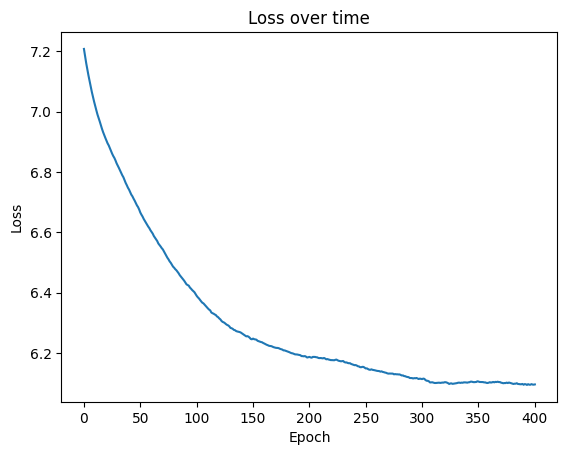

In [28]:
# plot the losses with smoothing
window_size = 100
avg = np.convolve(losses, np.ones(window_size), mode='valid') / window_size
plt.plot(avg)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Loss over time')
plt.show()